**Data Mining P6**

Langkah 1 : Preparation

In [5]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df = pd.read_excel("Datasets Superstore.xlsx")
df.head()

Saving Datasets Superstore.xlsx to Datasets Superstore.xlsx


,Row ID,Order ID,Order Date,Year,Month,Day,Ship Mode,Customer ID,Customer Name,Segment,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016,November,8,Second Class,CG-12520,Claire Gute,Consumer,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016,November,8,Second Class,CG-12520,Claire Gute,Consumer,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016,Juni,12,Second Class,DV-13045,Darrin Van Huff,Corporate,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015,Oktober,11,Standard Class,SO-20335,Sean O'Donnell,Consumer,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015,Oktober,11,Standard Class,SO-20335,Sean O'Donnell,Consumer,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Langkah 2 : Eksplorasi Data

In [6]:
df.info()
print("\nMissing Values:\n", df.isnull().sum())
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Year           9994 non-null   int64         
 4   Month          9994 non-null   object        
 5   Day            9994 non-null   int64         
 6   Ship Mode      9994 non-null   object        
 7   Customer ID    9994 non-null   object        
 8   Customer Name  9994 non-null   object        
 9   Segment        9994 non-null   object        
 10  Country        9994 non-null   object        
 11  City           9994 non-null   object        
 12  State          9994 non-null   object        
 13  Postal Code    9994 non-null   int64         
 14  Region         9994 non-null   object        
 15  Product ID     9994 n

Index(['Row ID', 'Order ID', 'Order Date', 'Year', 'Month', 'Day', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Langkah 3 : Visualisasi

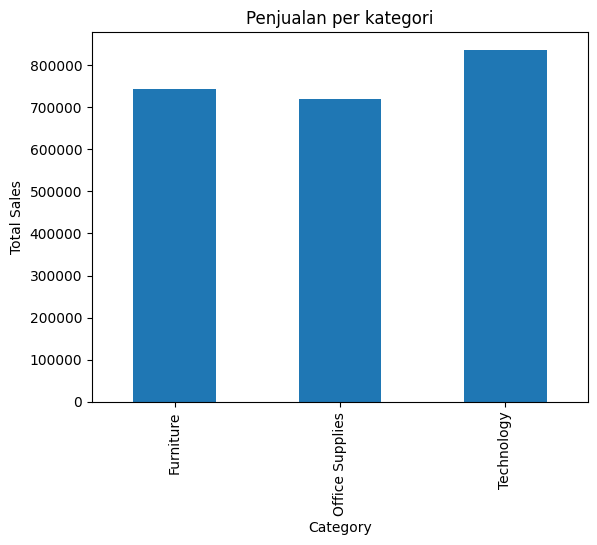

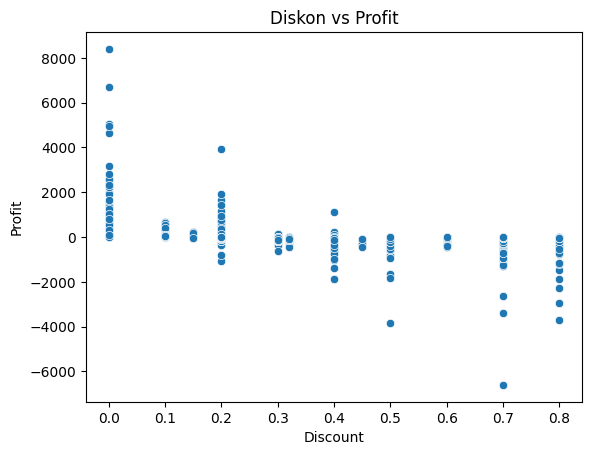

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

df.groupby('Category')['Sales'].sum().plot(kind='bar', title='Penjualan per kategori')
plt.ylabel('Total Sales')
plt.show()

sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title('Diskon vs Profit')
plt.show()

Langkah 4 : Klasifikasi Untung/Rugi (DecisionTree)

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df['Label'] = df['Profit'].apply(lambda x: 1 if x > 0 else 0)
features = df[['Sales', 'Discount', 'Quantity']].fillna(0)
labels = df['Label']

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       547
           1       0.96      0.96      0.96      2452

    accuracy                           0.93      2999
   macro avg       0.89      0.88      0.89      2999
weighted avg       0.93      0.93      0.93      2999

Confusion Matrix:
 [[ 441  106]
 [  93 2359]]


Klasifikasi K-Nearest Neighbors (K-NN)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df['Label'] = df['Profit'].apply(lambda x: 1 if x > 0 else 0)
features = df[['Sales', 'Discount', 'Quantity']].fillna(0)
labels = df['Label']

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)
model = KNeighborsClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.36      0.46       547
           1       0.87      0.96      0.91      2452

    accuracy                           0.85      2999
   macro avg       0.76      0.66      0.69      2999
weighted avg       0.83      0.85      0.83      2999

Confusion Matrix:
 [[ 197  350]
 [ 109 2343]]


Klasifikasi Artificial Neural Network (ANN)

In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df['Label'] = df['Profit'].apply(lambda x: 1 if x > 0 else 0)
features = df[['Sales', 'Discount', 'Quantity']].fillna(0)
labels = df['Label']

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)

model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.48      0.65       547
           1       0.90      1.00      0.95      2452

    accuracy                           0.91      2999
   macro avg       0.95      0.74      0.80      2999
weighted avg       0.92      0.91      0.89      2999

Confusion Matrix:
 [[ 264  283]
 [   0 2452]]


**Penjelasan**

1. Decision Tree

* Akurasi: 93%
* Keunggulan: Sangat baik dalam mengenali transaksi untung (precision & recall = 0.96).
* Kelemahan: Kurang presisi dalam mengenali transaksi rugi (recall = 0.81).

2. K-Nearest Neighbors (KNN)

* Akurasi: 85%
* Keunggulan: Masih cukup baik dalam mendeteksi transaksi untung (recall = 0.96).
* Kelemahan: Performa rendah untuk transaksi rugi (recall = 0.36, precision = 0.64).

3. Artificial Neural Network (MLPClassifier)

* Akurasi: 91%
* Keunggulan: Sangat andal untuk mengenali transaksi untung (recall = 1.00, precision = 0.90).
* Kelemahan: Deteksi transaksi rugi kurang konsisten (recall = 0.48 meskipun precision = 1.00).

**Kesimpulan**

Dari ketiga model klasifikasi yang diuji, Decision Tree menunjukkan performa paling seimbang, dengan akurasi tinggi (93%) dan kemampuan yang cukup baik dalam mendeteksi baik transaksi untung maupun rugi. KNN memang cukup baik dalam mengenali transaksi untung, namun sangat lemah dalam mengidentifikasi transaksi yang merugi, sehingga kurang cocok jika fokus utama adalah mendeteksi kerugian. Sementara itu, model Neural Network (MLPClassifier) mampu mengenali transaksi untung dengan sangat akurat, namun masih kurang andal dalam menangkap transaksi rugi. Secara keseluruhan, meskipun semua model bekerja baik untuk prediksi keuntungan, hanya Decision Tree yang menunjukkan keseimbangan performa yang layak jika tujuan analisis mencakup identifikasi kerugian.